# Interpretable Stratification of Functional Outcome and Rehabilitation LOS at Admission
**WCCI 2026 — Reproducibility Notebook**

This notebook reproduces the results reported in:
> *Interpretable Stratification of Functional Outcome and Rehabilitation Length of Stay at Admission*  
> WCCI 2026, Maastricht, Netherlands

**Tasks:**
- Task A: SCIM discharge 3-class stratification (Low / Medium / High)
- Task B: Rehabilitation LOS 3-class stratification (Short / Medium / Long)

**Models:** XGBoost, LightGBM, ExtraTrees, RandomForest, HistGradientBoosting  
**Split:** GroupShuffleSplit by `pid_anon` — patient-level, no leakage  
**Explainability:** SHAP global bar + local waterfall  

**Note on data:** Clinical data from the Swiss Paraplegic Centre cannot be shared due to  
privacy constraints. An anonymized feature export (no patient identifiers) is generated  
in Step 3 for methodological reproducibility.

## Step 1 — Imports

In [23]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    f1_score, balanced_accuracy_score
)
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)
from lightgbm import LGBMClassifier

try:
    from xgboost import XGBClassifier
    XGB_OK = True
except Exception:
    XGB_OK = False

try:
    import shap
    SHAP_OK = True
except Exception:
    SHAP_OK = False
    print('SHAP not found — run: pip install shap')

print(f'XGBoost : {XGB_OK}')
print(f'SHAP    : {SHAP_OK}')

XGBoost : True
SHAP    : True


## Step 2 — Configuration

All parameters are set here. Update `INPUT_PATH` to point to your local copy of the data.

In [55]:
# Path to input data — update this to your local file location
INPUT_PATH  = 'ML_Ready.xlsx'
OUT_DIR     = 'Interpretable Stratification of Functional Outcome  # and Rehabilitation Length of Stay at Admission'
os.makedirs(OUT_DIR, exist_ok=True)

# Reproducibility seed and split ratio
RANDOM_STATE = 42
TEST_SIZE    = 0.2

# Patient identifier column — used for group splitting only, never as a feature
GROUP_COL = 'pid_anon'

# SCIM outcome thresholds — p25/p75 computed on training set only
SCIM_Q_LOW  = 25
SCIM_Q_HIGH = 75

# LOS thresholds — asymmetric to handle right-skewed distribution
LOS_Q_LOW  = 33
LOS_Q_HIGH = 66

# Maximum test samples used for SHAP computation
SHAP_MAX_SAMPLES = 250

# Only keep rehab admission month/year for time anchoring
# Acute temporal features are dropped to prevent calendar leakage
KEEP_REHAB_TIME_ONLY = True

# Class labels for output
CLASS_LABELS_SCIM = {0: 'Low', 1: 'Medium', 2: 'High'}
CLASS_LABELS_LOS  = {0: 'Short', 1: 'Medium', 2: 'Long'}

# Set to a pid_anon value to run single-patient inference, None to skip
PREDICT_PID = "B黨ler_Franz_19480413_1"

print(f'Output directory: {OUT_DIR}')

Output directory: model_outputs_paper1


## Step 3 — Feature columns

This is the complete feature set used in the paper.  
An anonymized version (no `pid_anon`) is exported at the end of this cell for reproducibility.

In [25]:
ALLOWED_COLS = [
    # SCIM subscores — acute phase (admission and discharge)
    'acute_SP_SUB_adm', 'acute_AS_SUB_adm', 'acute_MH_SUB_adm', 'acute_MA_SUB_adm',
    'acute_SCIM_TOTAL_adm', 'acute_KF_SUB_adm',
    'acute_SP_SUB_dis', 'acute_AS_SUB_dis', 'acute_MH_SUB_dis', 'acute_MA_SUB_dis',
    'acute_SCIM_TOTAL_dis', 'acute_KF_SUB_dis',
    'acute_total_cost',

    # SCIM subscores — rehabilitation phase (admission and discharge)
    'rehab_SP_SUB_adm', 'rehab_AS_SUB_adm', 'rehab_MH_SUB_adm', 'rehab_MA_SUB_adm',
    'rehab_SCIM_TOTAL_adm', 'rehab_KF_SUB_adm',
    'rehab_SP_SUB_dis', 'rehab_AS_SUB_dis', 'rehab_MH_SUB_dis', 'rehab_MA_SUB_dis',
    'rehab_SCIM_TOTAL_dis', 'rehab_KF_SUB_dis',
    'rehab_total_cost',

    # Demographics and administrative variables
    'pid_anon', 'age_at_entry', 'icu_hours', 'icd_main', 'sex_label',

    # Length of stay
    'acute_LOS_days', 'rehab_LOS_days',

    # SCIM-derived transition and recovery features
    'rehab_SCIM_gain', 'total_SCIM_gain', 'acute_SCIM_gain',
    'rehab_SCIM_gain_per_day', 'rehab_recovery_velocity',
    'SCIM_acute_to_rehab_gap', 'early_deterioration_flag',
    'rehab_relative_gain', 'rehab_gain_vs_baseline',

    # Domain ratio features — proportion of function per SCIM domain
    'acute_mobility_ratio', 'acute_selfcare_ratio',
    'acute_resp_sphincter_ratio', 'acute_communication_ratio',

    # Comorbidity and ICU features
    'total_cost_episode', 'n_icd_codes', 'high_comorbidity_flag',
    'icu_exposed', 'icu_hours_per_LOS',

    # Temporal admission features
    # 'rehab_month_adm', 'rehab_year_adm',
    # 'acute_month_adm', 'acute_year_adm', 'acute_month_dis', 'acute_year_dis',
]

# Columns that identify the patient — excluded from the anonymized export
IDENTIFIER_COLS = ['pid_anon']

# The anonymized feature list is everything except the patient identifier
ANON_FEATURE_COLS = [c for c in ALLOWED_COLS if c not in IDENTIFIER_COLS]

print(f'Total columns defined  : {len(ALLOWED_COLS)}')
print(f'Anonymized features    : {len(ANON_FEATURE_COLS)}')
print(f'Identifier columns     : {IDENTIFIER_COLS}')

Total columns defined  : 51
Anonymized features    : 50
Identifier columns     : ['pid_anon']


## Step 4 — Helper functions

In [26]:
def to_numeric_safe(df):
    for col in df.columns:
        if df[col].dtype == 'object':
            cleaned = df[col].astype(str).str.replace("'", '', regex=False)
            df[col] = pd.to_numeric(cleaned, errors='ignore')
    return df


def make_3class(y, low_thr, high_thr):
    y   = np.asarray(y, dtype=float)
    out = np.zeros(len(y), dtype=int)
    out[(y > low_thr) & (y <= high_thr)] = 1
    out[y > high_thr] = 2
    return out


def get_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    return {
        'Accuracy':    float(accuracy_score(y_true, y_pred)),
        'BalancedAcc': float(balanced_accuracy_score(y_true, y_pred)),
        'MacroF1':     float(f1_score(y_true, y_pred, average='macro')),
        'CM_00': int(cm[0,0]), 'CM_01': int(cm[0,1]), 'CM_02': int(cm[0,2]),
        'CM_10': int(cm[1,0]), 'CM_11': int(cm[1,1]), 'CM_12': int(cm[1,2]),
        'CM_20': int(cm[2,0]), 'CM_21': int(cm[2,1]), 'CM_22': int(cm[2,2]),
    }


def build_preprocessor(X):
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]
    num_pipe = Pipeline([('imp', SimpleImputer(strategy='median'))])
    try:
        oh = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        oh = OneHotEncoder(handle_unknown='ignore', sparse=False)
    cat_pipe = Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('oh', oh)
    ])
    return ColumnTransformer(
        transformers=[('num', num_pipe, num_cols), ('cat', cat_pipe, cat_cols)],
        remainder='drop', sparse_threshold=0.0
    )


def group_split(X, y, groups, test_size=0.2, random_state=42):
    if groups is None:
        return train_test_split(X, y, test_size=test_size, random_state=random_state)
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    tr_idx, te_idx = next(gss.split(X, y, groups=groups))
    return (X.iloc[tr_idx].copy(), X.iloc[te_idx].copy(),
            y.iloc[tr_idx].copy(), y.iloc[te_idx].copy())


def pick_features(df, task):
    drop = set()
    if GROUP_COL in df.columns:
        drop.add(GROUP_COL)

    rehab_dis  = [c for c in df.columns if c.startswith('rehab_') and c.endswith('_dis')]
    posthoc    = [
        'rehab_SCIM_gain', 'total_SCIM_gain', 'acute_SCIM_gain',
        'rehab_SCIM_gain_per_day', 'rehab_recovery_velocity',
        'rehab_relative_gain', 'rehab_gain_vs_baseline', 'early_deterioration_flag',
    ]
    costs      = ['total_cost_episode', 'rehab_total_cost', 'acute_total_cost']
    time_drop  = (
        ['acute_month_adm', 'acute_year_adm', 'acute_month_dis', 'acute_year_dis']
        if KEEP_REHAB_TIME_ONLY else []
    )

    if task == 'SCIM':
        drop.add('rehab_SCIM_TOTAL_dis')
        drop |= set(rehab_dis)
        drop |= set([c for c in posthoc   if c in df.columns])
        drop |= set([c for c in costs     if c in df.columns])
        drop |= set([c for c in ['rehab_LOS_days', 'acute_LOS_days'] if c in df.columns])
        drop |= set([c for c in time_drop if c in df.columns])
    elif task == 'LOS':
        drop.add('rehab_LOS_days')
        drop |= set(rehab_dis)
        drop |= set([c for c in posthoc   if c in df.columns])
        drop |= set([c for c in costs     if c in df.columns])
        if 'rehab_SCIM_TOTAL_dis' in df.columns:
            drop.add('rehab_SCIM_TOTAL_dis')
        drop |= set([c for c in time_drop if c in df.columns])

    drop = [c for c in drop if c in df.columns]
    return [c for c in df.columns if c not in drop]


def get_feature_names(pre):
    if hasattr(pre, 'get_feature_names_out'):
        try:
            return [str(n) for n in pre.get_feature_names_out()]
        except Exception:
            pass
    names = []
    for name, trans, cols in pre.transformers_:
        if name == 'remainder':
            continue
        if hasattr(trans, 'get_feature_names_out'):
            try:
                names.extend([str(x) for x in trans.get_feature_names_out(cols)])
                continue
            except Exception:
                pass
        names.extend(
            [str(c) for c in cols]
            if isinstance(cols, (list, tuple, np.ndarray))
            else [str(cols)]
        )
    return names


def run_shap(model, X_enc):
    explainer = shap.TreeExplainer(model)
    return explainer.shap_values(X_enc), explainer.expected_value


def get_shap_1d(sv, base, cls):
    if isinstance(sv, list):
        vals = np.asarray(sv[cls]).reshape(-1)
        bval = base[cls] if isinstance(base, (list, np.ndarray)) else base
    else:
        vals = np.asarray(sv[0, :, cls]).reshape(-1)
        bval = base[cls] if isinstance(base, (list, np.ndarray)) else base
    return vals, bval


print('Helper functions ready.')

Helper functions ready.


## Step 5 — Load data and export anonymized feature file

The anonymized export contains all features used in training with `pid_anon` removed.  
It is saved to `model_outputs_paper1/anonymized_features.xlsx` for methodological reproducibility.

In [27]:
df_raw = pd.read_excel(INPUT_PATH)
df_raw.columns = df_raw.columns.str.strip()

keep = [c for c in ALLOWED_COLS if c in df_raw.columns]
df   = df_raw[keep].copy()
df   = to_numeric_safe(df)

use_group = (GROUP_COL in df.columns) and df[GROUP_COL].notna().any()

print(f'Dataset shape     : {df.shape}')
print(f'Group split on    : {GROUP_COL} = {use_group}')
print(f'Unique patients   : {df[GROUP_COL].nunique() if use_group else "N/A"}')

# Export anonymized feature file — pid_anon removed
anon_cols  = [c for c in ANON_FEATURE_COLS if c in df.columns]
df_anon    = df[anon_cols].copy()
anon_path  = os.path.join(OUT_DIR, 'anonymized_features.xlsx')
df_anon.to_excel(anon_path, index=False)

print(f'\nAnonymized export : {anon_path}')
print(f'Anonymized shape  : {df_anon.shape}')
print(f'Columns exported  : {anon_cols}')

Dataset shape     : (818, 51)
Group split on    : pid_anon = True
Unique patients   : 798

Anonymized export : model_outputs_paper1/anonymized_features.xlsx
Anonymized shape  : (818, 50)
Columns exported  : ['acute_SP_SUB_adm', 'acute_AS_SUB_adm', 'acute_MH_SUB_adm', 'acute_MA_SUB_adm', 'acute_SCIM_TOTAL_adm', 'acute_KF_SUB_adm', 'acute_SP_SUB_dis', 'acute_AS_SUB_dis', 'acute_MH_SUB_dis', 'acute_MA_SUB_dis', 'acute_SCIM_TOTAL_dis', 'acute_KF_SUB_dis', 'acute_total_cost', 'rehab_SP_SUB_adm', 'rehab_AS_SUB_adm', 'rehab_MH_SUB_adm', 'rehab_MA_SUB_adm', 'rehab_SCIM_TOTAL_adm', 'rehab_KF_SUB_adm', 'rehab_SP_SUB_dis', 'rehab_AS_SUB_dis', 'rehab_MH_SUB_dis', 'rehab_MA_SUB_dis', 'rehab_SCIM_TOTAL_dis', 'rehab_KF_SUB_dis', 'rehab_total_cost', 'age_at_entry', 'icu_hours', 'icd_main', 'sex_label', 'acute_LOS_days', 'rehab_LOS_days', 'rehab_SCIM_gain', 'total_SCIM_gain', 'acute_SCIM_gain', 'rehab_SCIM_gain_per_day', 'rehab_recovery_velocity', 'SCIM_acute_to_rehab_gap', 'early_deterioration_flag', 

## Step 6 — Task A: SCIM discharge 3-class

In [28]:
TARGET_SCIM = 'rehab_SCIM_TOTAL_dis'

dA = df.dropna(subset=[TARGET_SCIM]).copy()
dA[TARGET_SCIM] = pd.to_numeric(dA[TARGET_SCIM], errors='coerce')
dA = dA.dropna(subset=[TARGET_SCIM])

XA_cols = pick_features(dA, 'SCIM')
XA      = dA[XA_cols].copy()
yA_cont = dA[TARGET_SCIM].copy()

groupsA = dA[GROUP_COL] if use_group else None
XA_tr, XA_te, yA_tr_c, yA_te_c = group_split(
    XA, yA_cont, groupsA, TEST_SIZE, RANDOM_STATE)

# Thresholds derived from training set only — no leakage
scim_low  = float(np.nanpercentile(yA_tr_c.values, SCIM_Q_LOW))
scim_high = float(np.nanpercentile(yA_tr_c.values, SCIM_Q_HIGH))

yA_tr = make_3class(yA_tr_c.values, scim_low, scim_high)
yA_te = make_3class(yA_te_c.values, scim_low, scim_high)

print(f'SCIM task rows    : {len(dA)}')
print(f'Train / Test      : {len(XA_tr)} / {len(XA_te)}')
print(f'Thresholds        : Low ≤ {scim_low:.0f}  Medium ≤ {scim_high:.0f}  High > {scim_high:.0f}')
print(f'Train class dist  : {dict(zip(*np.unique(yA_tr, return_counts=True)))}')
print(f'Test  class dist  : {dict(zip(*np.unique(yA_te, return_counts=True)))}')
print(f'\nFeatures used ({len(XA_cols)}):')
for i, c in enumerate(XA_cols, 1):
    print(f'  {i:3d}. {c}')

SCIM task rows    : 818
Train / Test      : 653 / 165
Thresholds        : Low ≤ 22  Medium ≤ 67  High > 67
Train class dist  : {np.int64(0): np.int64(173), np.int64(1): np.int64(323), np.int64(2): np.int64(157)}
Test  class dist  : {np.int64(0): np.int64(42), np.int64(1): np.int64(77), np.int64(2): np.int64(46)}

Features used (31):
    1. acute_SP_SUB_adm
    2. acute_AS_SUB_adm
    3. acute_MH_SUB_adm
    4. acute_MA_SUB_adm
    5. acute_SCIM_TOTAL_adm
    6. acute_KF_SUB_adm
    7. acute_SP_SUB_dis
    8. acute_AS_SUB_dis
    9. acute_MH_SUB_dis
   10. acute_MA_SUB_dis
   11. acute_SCIM_TOTAL_dis
   12. acute_KF_SUB_dis
   13. rehab_SP_SUB_adm
   14. rehab_AS_SUB_adm
   15. rehab_MH_SUB_adm
   16. rehab_MA_SUB_adm
   17. rehab_SCIM_TOTAL_adm
   18. rehab_KF_SUB_adm
   19. age_at_entry
   20. icu_hours
   21. icd_main
   22. sex_label
   23. SCIM_acute_to_rehab_gap
   24. acute_mobility_ratio
   25. acute_selfcare_ratio
   26. acute_resp_sphincter_ratio
   27. acute_communication_rat

In [29]:
preA = build_preprocessor(XA_tr)

models_A = {
    'LightGBM': Pipeline([('pre', preA), ('m', LGBMClassifier(
        n_estimators=1500, learning_rate=0.03, num_leaves=63,
        subsample=0.85, colsample_bytree=0.85,
        objective='multiclass', num_class=3,
        random_state=RANDOM_STATE, n_jobs=-1))]),
    'ExtraTrees': Pipeline([('pre', preA), ('m', ExtraTreesClassifier(
        n_estimators=1200, min_samples_leaf=3,
        n_jobs=-1, random_state=RANDOM_STATE))]),
    'RandomForest': Pipeline([('pre', preA), ('m', RandomForestClassifier(
        n_estimators=900, min_samples_leaf=4,
        n_jobs=-1, random_state=RANDOM_STATE))]),
    'HistGB': Pipeline([('pre', preA), ('m', HistGradientBoostingClassifier(
        max_depth=6, learning_rate=0.06, max_iter=600,
        random_state=RANDOM_STATE))]),
}
if XGB_OK:
    models_A['XGBoost'] = Pipeline([('pre', preA), ('m', XGBClassifier(
        n_estimators=1800, learning_rate=0.03, max_depth=6,
        subsample=0.85, colsample_bytree=0.85,
        objective='multi:softprob', num_class=3, eval_metric='mlogloss',
        random_state=RANDOM_STATE, n_jobs=-1, tree_method='hist'))])

A_results = []
for name, pipe in models_A.items():
    pipe.fit(XA_tr, yA_tr)
    pred = pipe.predict(XA_te)
    rep  = get_metrics(yA_te, pred)
    rep['model'] = name
    A_results.append(rep)
    print(f'{name:15s}  Acc={rep["Accuracy"]:.3f}  '
          f'BalAcc={rep["BalancedAcc"]:.3f}  MacroF1={rep["MacroF1"]:.3f}')

df_A = pd.DataFrame(A_results).sort_values('Accuracy', ascending=False)
df_A[['model', 'Accuracy', 'BalancedAcc', 'MacroF1']].reset_index(drop=True)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000947 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1193
[LightGBM] [Info] Number of data points in the train set: 653, number of used features: 35
[LightGBM] [Info] Start training from score -1.328286
[LightGBM] [Info] Start training from score -0.703925
[LightGBM] [Info] Start training from score -1.425331
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

,model,Accuracy,BalancedAcc,MacroF1
0,XGBoost,0.800000,0.784522,0.795692
1,LightGBM,0.775758,0.762062,0.768879
2,RandomForest,0.775758,0.752619,0.761489
3,HistGB,0.751515,0.746283,0.752215
4,ExtraTrees,0.721212,0.678964,0.700317


In [30]:
A_out = os.path.join(OUT_DIR, 'TASK_A_SCIM')
os.makedirs(A_out, exist_ok=True)
df_A.to_excel(os.path.join(A_out, 'metrics_SCIM_3class.xlsx'), index=False)

# Save thresholds used for reproducibility
with open(os.path.join(A_out, 'SCIM_thresholds.txt'), 'w') as f:
    f.write(f'low_thr (p{SCIM_Q_LOW})  = {scim_low}\n')
    f.write(f'high_thr (p{SCIM_Q_HIGH}) = {scim_high}\n')

best_A_name = df_A.iloc[0]['model']
best_A_pipe = models_A[best_A_name]
print(f'Best SCIM model: {best_A_name}  Acc={df_A.iloc[0]["Accuracy"]:.3f}')
print(f'Thresholds saved to: {A_out}/SCIM_thresholds.txt')

Best SCIM model: XGBoost  Acc=0.800
Thresholds saved to: model_outputs_paper1/TASK_A_SCIM/SCIM_thresholds.txt


## Step 7 — Task A SHAP: global feature importance

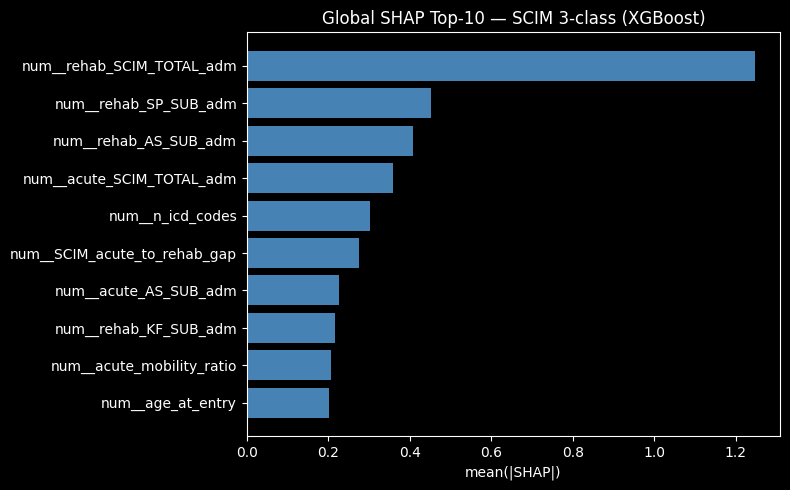

SCIM global SHAP saved.


In [31]:
if SHAP_OK:
    pre_A        = best_A_pipe.named_steps['pre']
    model_A      = best_A_pipe.named_steps['m']
    feat_names_A = get_feature_names(pre_A)

    X_shap_A = XA_te.sample(min(SHAP_MAX_SAMPLES, len(XA_te)), random_state=RANDOM_STATE)
    X_enc_A  = pre_A.transform(X_shap_A)
    sv_A, _  = run_shap(model_A, X_enc_A)

    if isinstance(sv_A, list):
        global_imp_A = np.mean(
            np.vstack([np.mean(np.abs(s), axis=0) for s in sv_A]), axis=0)
    else:
        global_imp_A = np.mean(np.abs(sv_A), axis=(0, 2))

    df_shap_A = (pd.DataFrame({'feature': feat_names_A, 'mean_abs_shap': global_imp_A})
                 .sort_values('mean_abs_shap', ascending=False).head(10))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(df_shap_A['feature'][::-1], df_shap_A['mean_abs_shap'][::-1], color='steelblue')
    ax.set_xlabel('mean(|SHAP|)')
    ax.set_title(f'Global SHAP Top-10 — SCIM 3-class ({best_A_name})')
    plt.tight_layout()
    plt.savefig(os.path.join(A_out, 'SCIM_3class_shap_global_bar.png'), dpi=200)
    plt.show()
    df_shap_A.to_excel(os.path.join(A_out, 'SCIM_3class_shap_top10.xlsx'), index=False)
    print('SCIM global SHAP saved.')
else:
    print('SHAP not available.')

## Step 8 — Task A SHAP: local waterfall (correct + wrong)

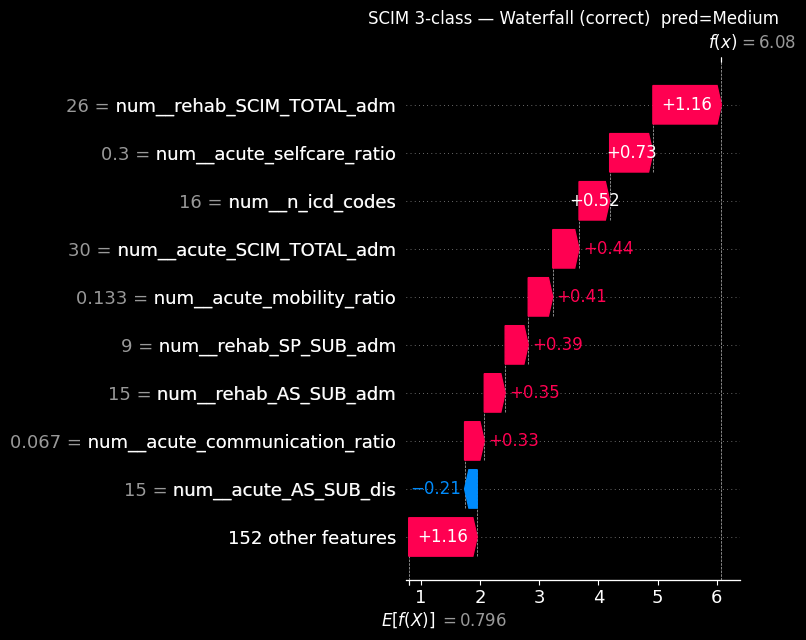

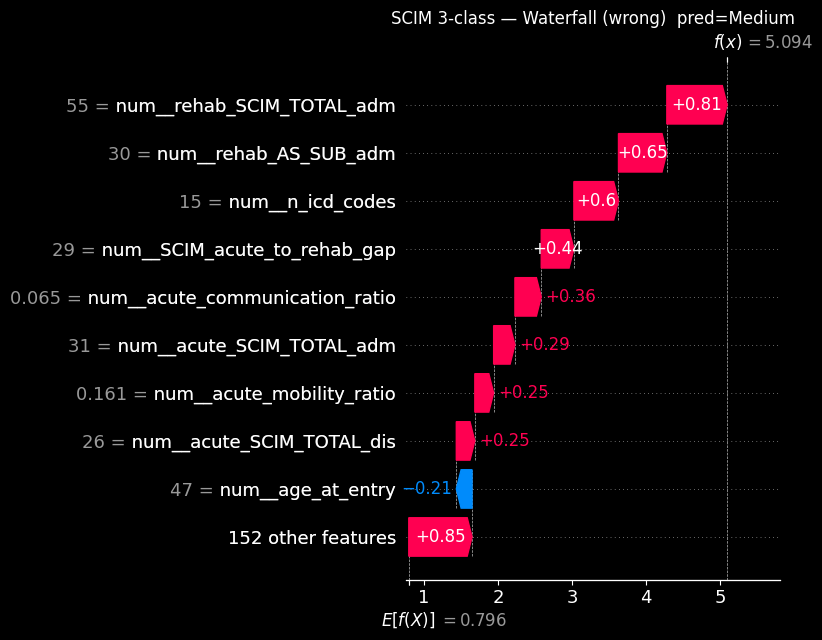

SCIM local waterfalls saved.


In [32]:
if SHAP_OK:
    pred_A  = best_A_pipe.predict(XA_te)
    proba_A = best_A_pipe.predict_proba(XA_te)
    conf_A  = np.max(proba_A, axis=1)

    correct_mask = pred_A == yA_te
    wrong_mask   = pred_A != yA_te

    best_correct_A = (XA_te.index[correct_mask][np.argmax(conf_A[correct_mask])]
                      if correct_mask.any() else None)
    best_wrong_A   = (XA_te.index[wrong_mask][np.argmax(conf_A[wrong_mask])]
                      if wrong_mask.any() else None)

    for tag, idx in [('correct', best_correct_A), ('wrong', best_wrong_A)]:
        if idx is None:
            continue
        x_enc_one        = pre_A.transform(XA_te.loc[[idx]])
        sv_one, base_one = run_shap(model_A, x_enc_one)
        pred_cls         = int(best_A_pipe.predict(XA_te.loc[[idx]])[0])
        vals, bval       = get_shap_1d(sv_one, base_one, pred_cls)

        exp = shap.Explanation(
            values=vals, base_values=bval,
            data=np.asarray(x_enc_one).reshape(-1),
            feature_names=feat_names_A
        )
        plt.figure()
        shap.plots.waterfall(exp, max_display=10, show=False)
        plt.title(f'SCIM 3-class — Waterfall ({tag})  '
                  f'pred={CLASS_LABELS_SCIM[pred_cls]}')
        plt.tight_layout()
        plt.savefig(os.path.join(A_out, f'SCIM_3class_waterfall_{tag}.png'), dpi=220)
        plt.show()
    print('SCIM local waterfalls saved.')
else:
    print('SHAP not available.')

## Step 9 — Task B: Rehabilitation LOS 3-class

In [33]:
TARGET_LOS = 'rehab_LOS_days'

dB = df.dropna(subset=[TARGET_LOS]).copy()
dB[TARGET_LOS] = pd.to_numeric(dB[TARGET_LOS], errors='coerce')
dB = dB.dropna(subset=[TARGET_LOS])

XB_cols = pick_features(dB, 'LOS')
XB      = dB[XB_cols].copy()
yB_cont = dB[TARGET_LOS].copy()

groupsB = dB[GROUP_COL] if use_group else None
XB_tr, XB_te, yB_tr_c, yB_te_c = group_split(
    XB, yB_cont, groupsB, TEST_SIZE, RANDOM_STATE)

los_low  = float(np.nanpercentile(yB_tr_c.values, LOS_Q_LOW))
los_high = float(np.nanpercentile(yB_tr_c.values, LOS_Q_HIGH))

yB_tr = make_3class(yB_tr_c.values, los_low, los_high)
yB_te = make_3class(yB_te_c.values, los_low, los_high)

print(f'LOS task rows     : {len(dB)}')
print(f'Train / Test      : {len(XB_tr)} / {len(XB_te)}')
print(f'Thresholds        : Short ≤ {los_low:.1f}d  Medium ≤ {los_high:.1f}d  Long > {los_high:.1f}d')
print(f'Train class dist  : {dict(zip(*np.unique(yB_tr, return_counts=True)))}')
print(f'Test  class dist  : {dict(zip(*np.unique(yB_te, return_counts=True)))}')
print(f'\nFeatures used ({len(XB_cols)}):')
for i, c in enumerate(XB_cols, 1):
    print(f'  {i:3d}. {c}')

LOS task rows     : 788
Train / Test      : 629 / 159
Thresholds        : Short ≤ 29.2d  Medium ≤ 183.0d  Long > 183.0d
Train class dist  : {np.int64(0): np.int64(208), np.int64(1): np.int64(208), np.int64(2): np.int64(213)}
Test  class dist  : {np.int64(0): np.int64(49), np.int64(1): np.int64(52), np.int64(2): np.int64(58)}

Features used (32):
    1. acute_SP_SUB_adm
    2. acute_AS_SUB_adm
    3. acute_MH_SUB_adm
    4. acute_MA_SUB_adm
    5. acute_SCIM_TOTAL_adm
    6. acute_KF_SUB_adm
    7. acute_SP_SUB_dis
    8. acute_AS_SUB_dis
    9. acute_MH_SUB_dis
   10. acute_MA_SUB_dis
   11. acute_SCIM_TOTAL_dis
   12. acute_KF_SUB_dis
   13. rehab_SP_SUB_adm
   14. rehab_AS_SUB_adm
   15. rehab_MH_SUB_adm
   16. rehab_MA_SUB_adm
   17. rehab_SCIM_TOTAL_adm
   18. rehab_KF_SUB_adm
   19. age_at_entry
   20. icu_hours
   21. icd_main
   22. sex_label
   23. acute_LOS_days
   24. SCIM_acute_to_rehab_gap
   25. acute_mobility_ratio
   26. acute_selfcare_ratio
   27. acute_resp_sphincter_r

In [34]:
preB = build_preprocessor(XB_tr)

models_B = {
    'LightGBM': Pipeline([('pre', preB), ('m', LGBMClassifier(
        n_estimators=1500, learning_rate=0.03, num_leaves=63,
        subsample=0.85, colsample_bytree=0.85,
        objective='multiclass', num_class=3,
        random_state=RANDOM_STATE, n_jobs=-1))]),
    'ExtraTrees': Pipeline([('pre', preB), ('m', ExtraTreesClassifier(
        n_estimators=1200, min_samples_leaf=3,
        n_jobs=-1, random_state=RANDOM_STATE))]),
    'RandomForest': Pipeline([('pre', preB), ('m', RandomForestClassifier(
        n_estimators=900, min_samples_leaf=4,
        n_jobs=-1, random_state=RANDOM_STATE))]),
    'HistGB': Pipeline([('pre', preB), ('m', HistGradientBoostingClassifier(
        max_depth=6, learning_rate=0.06, max_iter=600,
        random_state=RANDOM_STATE))]),
}
if XGB_OK:
    models_B['XGBoost'] = Pipeline([('pre', preB), ('m', XGBClassifier(
        n_estimators=1600, learning_rate=0.03, max_depth=6,
        subsample=0.85, colsample_bytree=0.85,
        objective='multi:softprob', num_class=3, eval_metric='mlogloss',
        random_state=RANDOM_STATE, n_jobs=-1, tree_method='hist'))])

B_results = []
for name, pipe in models_B.items():
    pipe.fit(XB_tr, yB_tr)
    pred = pipe.predict(XB_te)
    rep  = get_metrics(yB_te, pred)
    rep['model'] = name
    B_results.append(rep)
    print(f'{name:15s}  Acc={rep["Accuracy"]:.3f}  '
          f'BalAcc={rep["BalancedAcc"]:.3f}  MacroF1={rep["MacroF1"]:.3f}')

df_B = pd.DataFrame(B_results).sort_values('Accuracy', ascending=False)
df_B[['model', 'Accuracy', 'BalancedAcc', 'MacroF1']].reset_index(drop=True)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001049 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1252
[LightGBM] [Info] Number of data points in the train set: 629, number of used features: 36
[LightGBM] [Info] Start training from score -1.106593
[LightGBM] [Info] Start training from score -1.106593
[LightGBM] [Info] Start training from score -1.082839
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

,model,Accuracy,BalancedAcc,MacroF1
0,ExtraTrees,0.522013,0.510236,0.495367
1,RandomForest,0.484277,0.468878,0.444488
2,LightGBM,0.465409,0.460745,0.459149
3,HistGB,0.465409,0.460866,0.461135
4,XGBoost,0.452830,0.449372,0.450070


In [35]:
B_out = os.path.join(OUT_DIR, 'TASK_B_LOS')
os.makedirs(B_out, exist_ok=True)
df_B.to_excel(os.path.join(B_out, 'metrics_LOS_3class.xlsx'), index=False)

with open(os.path.join(B_out, 'LOS_thresholds.txt'), 'w') as f:
    f.write(f'low_thr (p{LOS_Q_LOW})  = {los_low}\n')
    f.write(f'high_thr (p{LOS_Q_HIGH}) = {los_high}\n')

best_B_name = df_B.iloc[0]['model']
best_B_pipe = models_B[best_B_name]
print(f'Best LOS model: {best_B_name}  Acc={df_B.iloc[0]["Accuracy"]:.3f}')

Best LOS model: ExtraTrees  Acc=0.522


## Step 10 — Task B SHAP: global importance

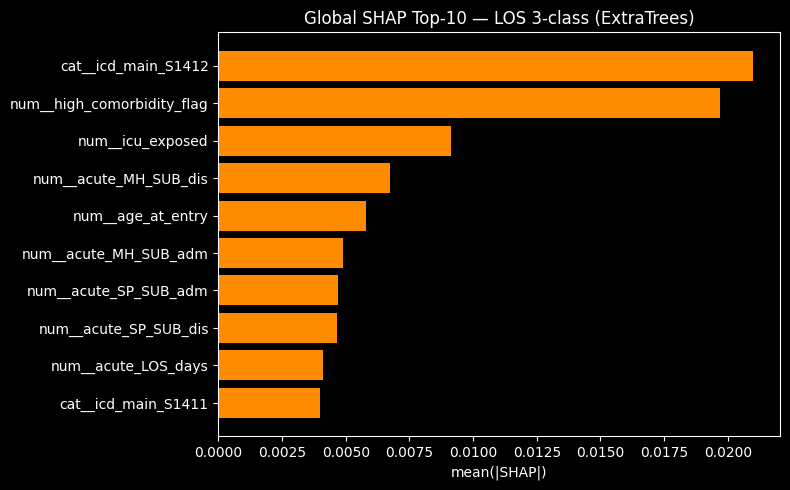

LOS global SHAP saved.


In [36]:
if SHAP_OK:
    pre_B        = best_B_pipe.named_steps['pre']
    model_B      = best_B_pipe.named_steps['m']
    feat_names_B = get_feature_names(pre_B)

    X_shap_B = XB_te.sample(min(SHAP_MAX_SAMPLES, len(XB_te)), random_state=RANDOM_STATE)
    X_enc_B  = pre_B.transform(X_shap_B)
    sv_B, _  = run_shap(model_B, X_enc_B)

    if isinstance(sv_B, list):
        global_imp_B = np.mean(
            np.vstack([np.mean(np.abs(s), axis=0) for s in sv_B]), axis=0)
    else:
        global_imp_B = np.mean(np.abs(sv_B), axis=(0, 2))

    df_shap_B = (pd.DataFrame({'feature': feat_names_B, 'mean_abs_shap': global_imp_B})
                 .sort_values('mean_abs_shap', ascending=False).head(10))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(df_shap_B['feature'][::-1], df_shap_B['mean_abs_shap'][::-1], color='darkorange')
    ax.set_xlabel('mean(|SHAP|)')
    ax.set_title(f'Global SHAP Top-10 — LOS 3-class ({best_B_name})')
    plt.tight_layout()
    plt.savefig(os.path.join(B_out, 'LOS_3class_shap_global_bar.png'), dpi=200)
    plt.show()
    df_shap_B.to_excel(os.path.join(B_out, 'LOS_3class_shap_top10.xlsx'), index=False)
    print('LOS global SHAP saved.')
else:
    print('SHAP not available.')

## Step 11 — Task B SHAP: local waterfall

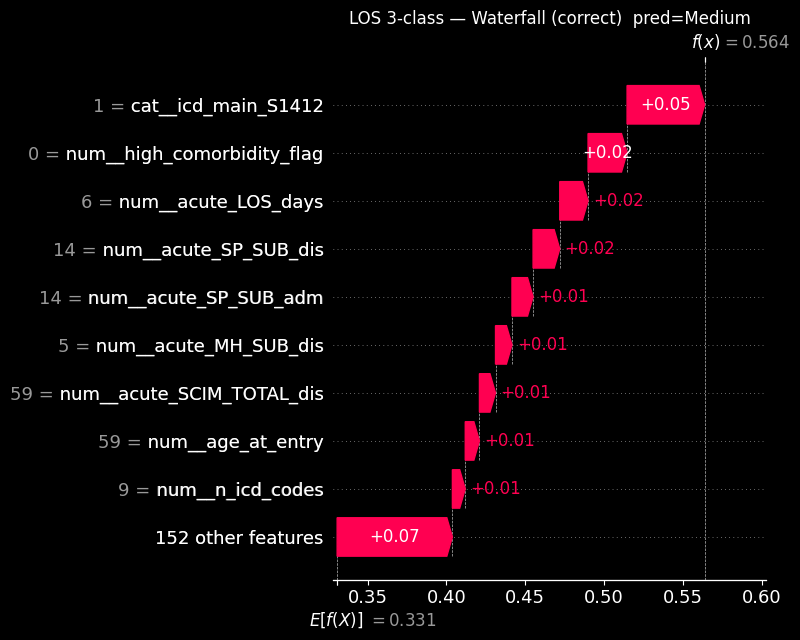

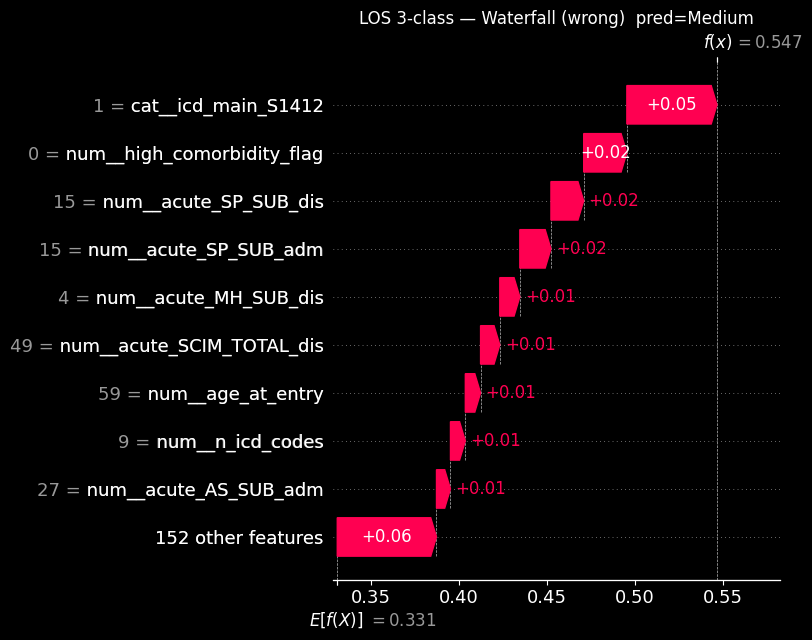

LOS local waterfalls saved.


In [37]:
if SHAP_OK:
    pred_B  = best_B_pipe.predict(XB_te)
    proba_B = best_B_pipe.predict_proba(XB_te)
    conf_B  = np.max(proba_B, axis=1)

    correct_mask_B = pred_B == yB_te
    wrong_mask_B   = pred_B != yB_te

    best_correct_B = (XB_te.index[correct_mask_B][np.argmax(conf_B[correct_mask_B])]
                      if correct_mask_B.any() else None)
    best_wrong_B   = (XB_te.index[wrong_mask_B][np.argmax(conf_B[wrong_mask_B])]
                      if wrong_mask_B.any() else None)

    for tag, idx in [('correct', best_correct_B), ('wrong', best_wrong_B)]:
        if idx is None:
            continue
        x_enc_one        = pre_B.transform(XB_te.loc[[idx]])
        sv_one, base_one = run_shap(model_B, x_enc_one)
        pred_cls         = int(best_B_pipe.predict(XB_te.loc[[idx]])[0])
        vals, bval       = get_shap_1d(sv_one, base_one, pred_cls)

        exp = shap.Explanation(
            values=vals, base_values=bval,
            data=np.asarray(x_enc_one).reshape(-1),
            feature_names=feat_names_B
        )
        plt.figure()
        shap.plots.waterfall(exp, max_display=10, show=False)
        plt.title(f'LOS 3-class — Waterfall ({tag})  '
                  f'pred={CLASS_LABELS_LOS[pred_cls]}')
        plt.tight_layout()
        plt.savefig(os.path.join(B_out, f'LOS_3class_waterfall_{tag}.png'), dpi=220)
        plt.show()
    print('LOS local waterfalls saved.')
else:
    print('SHAP not available.')

## Step 12 — Patient inference (optional)

Set `PREDICT_PID` in Step 2 to a valid `pid_anon` value to predict a single patient.

Running inference for: B黨ler_Franz_19480413_1

[SCIM discharge]
  Predicted  : 0 → Low
  Confidence : 97.9%
  All proba  : {'Low': '97.9%', 'Medium': '2.1%', 'High': '0.0%'}


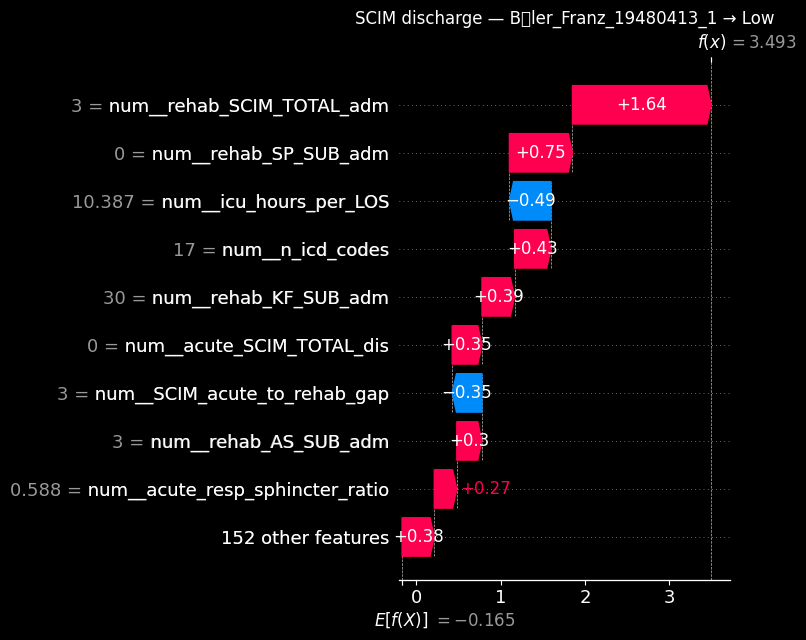


[LOS class]
  Predicted  : 2 → Long
  Confidence : 51.0%
  All proba  : {'Short': '21.8%', 'Medium': '27.2%', 'Long': '51.0%'}


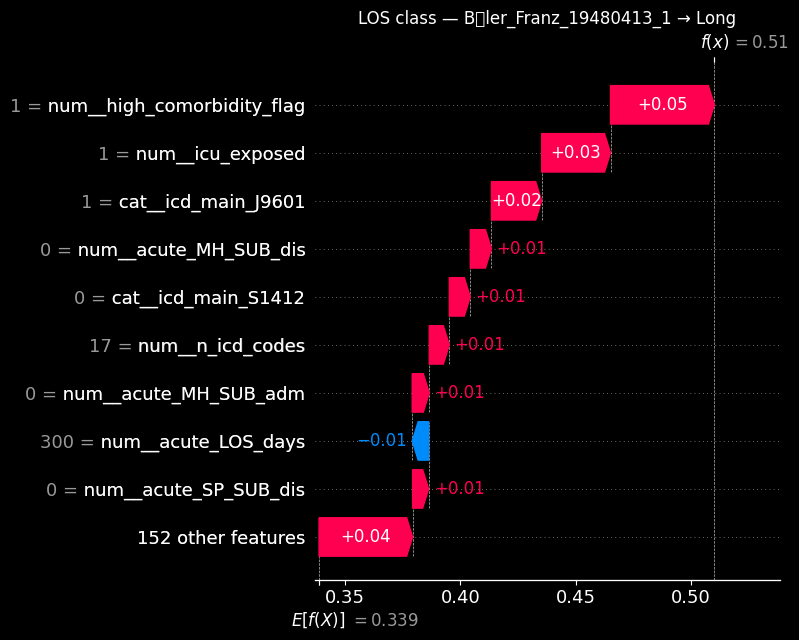

In [56]:
if PREDICT_PID is not None:
    inf_dir = os.path.join(OUT_DIR, 'inference')
    os.makedirs(inf_dir, exist_ok=True)

    patient_rows = df[df['pid_anon'] == PREDICT_PID]
    if len(patient_rows) == 0:
        print(f'pid_anon "{PREDICT_PID}" not found.')
    else:
        patient_row = patient_rows.iloc[[0]]
        print(f'Running inference for: {PREDICT_PID}')

        for task_label, pipe, feat_cols, class_labels, prefix in [
            ('SCIM discharge', best_A_pipe, XA_cols, CLASS_LABELS_SCIM, 'SCIM'),
            ('LOS class',      best_B_pipe, XB_cols, CLASS_LABELS_LOS,  'LOS'),
        ]:
            avail = [c for c in feat_cols if c in patient_row.columns]
            X_pat = patient_row[avail].copy()
            for c in [cc for cc in feat_cols if cc not in avail]:
                X_pat[c] = np.nan
            X_pat = X_pat[feat_cols]

            pred_cls = int(pipe.predict(X_pat)[0])
            proba    = pipe.predict_proba(X_pat)[0]

            print(f'\n[{task_label}]')
            print(f'  Predicted  : {pred_cls} → {class_labels[pred_cls]}')
            print(f'  Confidence : {proba[pred_cls]:.1%}')
            print(f'  All proba  : '
                  f'{ {class_labels[i]: f"{p:.1%}" for i,p in enumerate(proba)} }')

            if SHAP_OK:
                pre_inf    = pipe.named_steps['pre']
                mod_inf    = pipe.named_steps['m']
                fn_inf     = get_feature_names(pre_inf)
                x_enc      = pre_inf.transform(X_pat)
                sv_i, bv_i = run_shap(mod_inf, x_enc)
                vals, bval = get_shap_1d(sv_i, bv_i, pred_cls)

                exp = shap.Explanation(
                    values=vals, base_values=bval,
                    data=np.asarray(x_enc).reshape(-1),
                    feature_names=fn_inf
                )
                plt.figure()
                shap.plots.waterfall(exp, max_display=10, show=False)
                plt.title(f'{task_label} — {PREDICT_PID} → {class_labels[pred_cls]}')
                plt.tight_layout()
                plt.savefig(
                    os.path.join(inf_dir, f'{prefix}_{PREDICT_PID}_waterfall.png'),
                    dpi=220
                )
                plt.show()
else:
    print('No inference requested.')
    print('Set PREDICT_PID in Step 2 to predict a specific patient.')

In [46]:
idx = 627
print(exB2.loc[idx, [
    'age_at_entry', 'sex_label', 'icd_main',
    'acute_SCIM_TOTAL_adm', 'acute_SCIM_TOTAL_dis',
    'rehab_SCIM_TOTAL_adm', 'acute_LOS_days',
    'icu_hours', 'pred_confidence',
    'true_LOS_class', 'pred_LOS_class'
]])

age_at_entry                28.0
sex_label                 female
icd_main                   S1412
acute_SCIM_TOTAL_adm           8
acute_SCIM_TOTAL_dis           8
rehab_SCIM_TOTAL_adm          33
acute_LOS_days             249.0
icu_hours                  358.0
pred_confidence         0.474894
true_LOS_class                 2
pred_LOS_class                 2
Name: 627, dtype: object


## Step 13 — Results summary

In [47]:
print('=' * 60)
print('  PAPER 1 — RESULTS SUMMARY')
print('=' * 60)
print(f'\nCohort            : {len(df)} episodes')
print(f'SCIM train/test   : {len(XA_tr)} / {len(XA_te)}')
print(f'LOS  train/test   : {len(XB_tr)} / {len(XB_te)}')
print(f'\nSCIM thresholds   : Low ≤ {scim_low:.0f}  Medium ≤ {scim_high:.0f}  High > {scim_high:.0f}')
print(f'LOS  thresholds   : Short ≤ {los_low:.1f}d  Medium ≤ {los_high:.1f}d  Long > {los_high:.1f}d')

print(f'\n--- Task A: SCIM discharge 3-class (best: {best_A_name}) ---')
print(df_A[['model', 'Accuracy', 'BalancedAcc', 'MacroF1']].to_string(index=False))

print(f'\n--- Task B: Rehabilitation LOS 3-class (best: {best_B_name}) ---')
print(df_B[['model', 'Accuracy', 'BalancedAcc', 'MacroF1']].to_string(index=False))

print(f'\nAll outputs saved to : {OUT_DIR}')
print(f'Anonymized features  : {OUT_DIR}/anonymized_features.xlsx')
print('=' * 60)

  PAPER 1 — RESULTS SUMMARY

Cohort            : 818 episodes
SCIM train/test   : 653 / 165
LOS  train/test   : 629 / 159

SCIM thresholds   : Low ≤ 22  Medium ≤ 67  High > 67
LOS  thresholds   : Short ≤ 29.2d  Medium ≤ 183.0d  Long > 183.0d

--- Task A: SCIM discharge 3-class (best: XGBoost) ---
       model  Accuracy  BalancedAcc  MacroF1
     XGBoost  0.800000     0.784522 0.795692
    LightGBM  0.775758     0.762062 0.768879
RandomForest  0.775758     0.752619 0.761489
      HistGB  0.751515     0.746283 0.752215
  ExtraTrees  0.721212     0.678964 0.700317

--- Task B: Rehabilitation LOS 3-class (best: ExtraTrees) ---
       model  Accuracy  BalancedAcc  MacroF1
  ExtraTrees  0.522013     0.510236 0.495367
RandomForest  0.484277     0.468878 0.444488
    LightGBM  0.465409     0.460745 0.459149
      HistGB  0.465409     0.460866 0.461135
     XGBoost  0.452830     0.449372 0.450070

All outputs saved to : model_outputs_paper1
Anonymized features  : model_outputs_paper1/anonymized